# Competitor Performance & Sentiment Analysis

In [1]:
# Install if needed
# !pip install pandas numpy matplotlib textblob

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob

In [3]:
# Step 1: Generate Sample Data
np.random.seed(42)
brands = ['BrandA','BrandB','BrandC']
dates = pd.date_range(start='2025-01-01', periods=100)

data = []
for date in dates:
    for brand in brands:
        post = f"{brand} launches new product"
        likes = np.random.randint(100,1000)
        comments = np.random.randint(10,200)
        shares = np.random.randint(5,100)
        data.append([date, brand, post, likes, comments, shares])

df = pd.DataFrame(data, columns=['Date','Brand','Post','Likes','Comments','Shares'])
df.head()

,Date,Brand,Post,Likes,Comments,Shares
0,2025-01-01,BrandA,BrandA launches new product,202,189,97
1,2025-01-01,BrandB,BrandB launches new product,370,116,76
2,2025-01-01,BrandC,BrandC launches new product,800,30,87
3,2025-01-02,BrandA,BrandA launches new product,314,84,79
4,2025-01-02,BrandB,BrandB launches new product,187,126,28


In [4]:
# Step 2: Calculate Engagement
df['Engagement'] = df['Likes'] + df['Comments'] + df['Shares']
df.head()

,Date,Brand,Post,Likes,Comments,Shares,Engagement
0,2025-01-01,BrandA,BrandA launches new product,202,189,97,488
1,2025-01-01,BrandB,BrandB launches new product,370,116,76,562
2,2025-01-01,BrandC,BrandC launches new product,800,30,87,917
3,2025-01-02,BrandA,BrandA launches new product,314,84,79,477
4,2025-01-02,BrandB,BrandB launches new product,187,126,28,341


In [5]:
# Step 3: Competitor Performance
performance = df.groupby('Brand')['Engagement'].mean().reset_index()
performance

,Brand,Engagement
0,BrandA,696.61
1,BrandB,706.93
2,BrandC,695.14


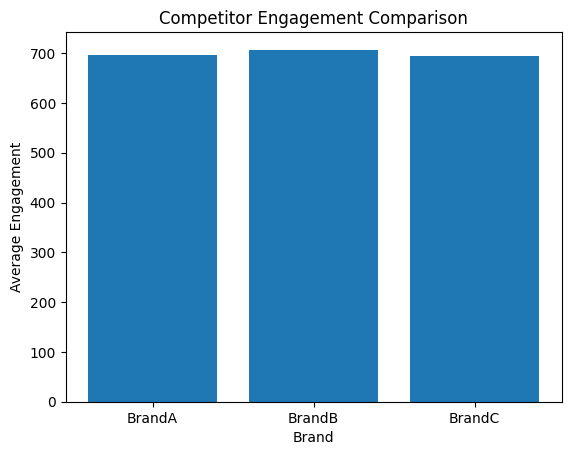

In [6]:
# Step 4: Visualization
plt.figure()
plt.bar(performance['Brand'], performance['Engagement'])
plt.xlabel('Brand')
plt.ylabel('Average Engagement')
plt.title('Competitor Engagement Comparison')
plt.show()

<Figure size 640x480 with 0 Axes>

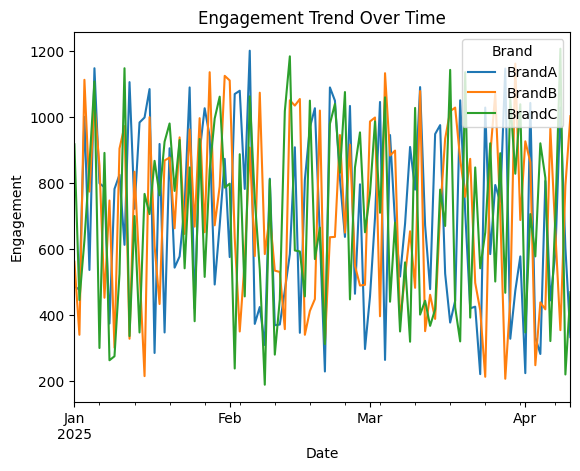

In [7]:
# Step 5: Trend Over Time
trend = df.groupby(['Date','Brand'])['Engagement'].mean().unstack()
plt.figure()
trend.plot()
plt.title('Engagement Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Engagement')
plt.show()

In [8]:
# Step 6: Sentiment Analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['Sentiment'] = df['Post'].apply(get_sentiment)

sentiment_summary = df.groupby('Brand')['Sentiment'].mean().reset_index()
sentiment_summary

,Brand,Sentiment
0,BrandA,0.136364
1,BrandB,0.136364
2,BrandC,0.136364


In [9]:
# Conclusion
print('Insights:')
print('- Compare engagement across brands')
print('- Analyze trends over time')
print('- Use sentiment for brand perception')

Insights:
- Compare engagement across brands
- Analyze trends over time
- Use sentiment for brand perception
